# Agrupamento de variedades de arroz

A base de dados é composta por **45** características e **2'091** entradas.


In [94]:
import pandas as pd

df = pd.read_csv("data/trabalho3_dados_1.csv")

df.columns = [
    "hectares",
    "agriblock",
    "variety",
    "soil_type",
    "seed_rate_kg",
    "lp_mainfield_tonnes",
    "nursery",
    "nursery_area_cents",
    "lp_nursery_area_tonnes",
    "dap_20days",
    "weed_28d_thiobencarb",
    "urea_40days",
    "potash_50days",
    "micronutrients_70days",
    "pesticide_60day_ml",
    "rainfall_d1_d30_mm",
    "irrigation_d1_d30_mm",
    "rainfall_d30_d50_mm",
    "irrigation_d30_d50_mm",
    "rainfall_d51_d70_mm",
    "irrigation_d51_d70_mm",
    "rainfall_d71_d105_mm",
    "irrigation_d71_d105_mm",
    "min_temp_d1_d30_c",
    "max_temp_d1_d30_c",
    "min_temp_d31_d60_c",
    "max_temp_d31_d60_c",
    "min_temp_d61_d90_c",
    "max_temp_d61_d90_c",
    "min_temp_d91_d120_c",
    "max_temp_d91_d120_c",
    "wind_speed_d1_d30_knots",
    "wind_speed_d31_d60_knots",
    "wind_speed_d61_d90_knots",
    "wind_speed_d91_d120_knots",
    "wind_direction_d1_d30",
    "wind_direction_d31_d60",
    "wind_direction_d61_d90",
    "wind_direction_d91_d120",
    "relative_humidity_d1_d30_pct",
    "relative_humidity_d31_d60_pct",
    "relative_humidity_d61_d90_pct",
    "relative_humidity_d91_d120_pct",
    "trash_bundles",
    "paddy_yield_kg",
]

In [95]:
%%html
<style>
table > caption,
table > tbody > tr > th {
    font-weight: bold;
} 
</style>

In [96]:
from typing import Literal

import matplotlib.pyplot as plt
from IPython.display import HTML, display


def get_numerical_range(
    series: pd.Series,
):
    min_value, max_value = series.min(), series.max()
    if hasattr(min_value, "strftime") and hasattr(max_value, "strftime"):
        min_text = min_value.strftime("%Y-%m-%d")
        max_text = max_value.strftime("%Y-%m-%d")
    else:
        min_text = str(min_value)
        max_text = str(max_value)
    return f"[{min_text}, {max_text}]"


def display_column_description(
    name: str,
    series: pd.Series,
    type_name: str,
    description: str,
    feature_type: Literal["categorical", "numerical", "other"] = "other",
):
    block_to_display = f"<table><caption>{name}</caption><tbody>"

    block_to_display += f"""
    <tr><td colspan="3" style="text-align: center;">{description}</td></tr>
    <tr><th>Identificador</th><td colspan="2">{series.name}</td></tr>
    <tr><th>Tipo</th><td colspan="2">{type_name}</td></tr>"""

    if feature_type == "categorical":
        values = sorted(series.dropna().unique().tolist())
        block_to_display += f"Valores possíveis: {len(values)} {values!s}"

    elif feature_type == "numerical":
        block_to_display += f"""<tr><th>Intervalo</th><td colspan="2">{get_numerical_range(series)}</td></tr>"""
        block_to_display += f"""
        <tr><th>Média</th><td colspan="2">{series.mean():.2}</td></tr>
        <tr><th>Mediana</th><td colspan="2">{series.median():.2}</td></tr>
        <tr><th>Desvio padrão</th><td colspan="2">{series.std():.2}</td></tr>
        <tr><th rowspan="5">Percentil</th><th>Percentil 05%</th><td>{series.quantile(0.05)}</td></tr>
        <tr><th>Percentil 25%</th><td>{series.quantile(0.25)}</td></tr>
        <tr><th>Percentil 50%</th><td>{series.quantile(0.5)}</td></tr>
        <tr><th>Percentil 75%</th><td>{series.quantile(0.75)}</td></tr>
        <tr><th>Percentil 95%</th><td>{series.quantile(0.95)}</td></tr>"""
        plt.boxplot(series.dropna())
        plt.xlabel("Boxplot")
        plt.ylabel(name)

    display(HTML(block_to_display + "</tbody></table>"))
    plt.show()


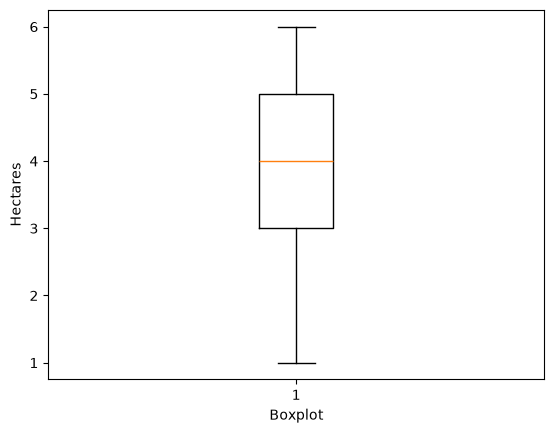

In [97]:
display_column_description(
    name="Hectares",
    series=df.hectares,
    type_name="Inteiro",
    description="Área de plantação.",
    feature_type="numerical",
)